# Hafta 6: İkili Dizi Hizalama I: Dinamik Programlama ve Needleman–Wunsch

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Hizalamanın biyolojik anlamını (homoloji, benzerlik, özdeşlik) ayırt etmek.
2. Puanlama şemasını (eşleşme, uyumsuzluk, boşluk cezası) tanımlamak.
3. Needleman–Wunsch global hizalama algoritmasını **elle** ve **Python'da** uygulamak (doldurma + geri izleme).
4. `Bio.Align.PairwiseAligner` ile hizalama yapmak, sonuçları yorumlamak ve algoritmanın karmaşıklığını ölçmek.

**Veri:** `protein_ailesi.fasta` (sentetik protein ailesi)

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_protein_ailesi(klasor="veri"):
    """protein_ailesi.fasta (hizasız), protein_ailesi_hizali.aln (gerçek MSA, Clustal)."""
    import os, random
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord
    from Bio.Align import MultipleSeqAlignment
    from Bio import SeqIO, AlignIO
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(2026)
    aa = "ACDEFGHIKLMNPQRSTVWY"
    frek = [8.3, 1.4, 5.5, 6.8, 3.9, 7.1, 2.3, 5.9, 5.8, 9.7, 2.4, 4.1, 4.7, 3.9, 5.4, 6.6, 5.3, 6.9, 1.1, 2.9]
    # Yer değiştirme olasılıkları BLOSUM62'den türetilir: P(b|a) ∝ p_b * 2^(s(a,b)/2)
    from Bio.Align import substitution_matrices
    B62 = substitution_matrices.load("BLOSUM62")
    gecis = {a: [0 if b == a else frek[j] * 2 ** (B62[a][b] / 2) for j, b in enumerate(aa)] for a in aa}
    L = 160
    ata = ["M"] + rng.choices(aa, weights=frek, k=L - 1)
    korunmus = set(rng.sample(range(1, L), 35)) | {0}

    def evrim(dizi, t):
        yeni = list(dizi)
        for i in range(len(yeni)):
            if yeni[i] == "-" or i in korunmus:
                continue
            if rng.random() < t:
                yeni[i] = rng.choices(aa, weights=gecis[yeni[i]])[0]
        if rng.random() < t * 2.5:                      # delesyon olayı
            u = rng.randint(1, 5)
            b = rng.randint(5, L - u - 5)
            if not any(k in korunmus for k in range(b, b + u)):
                for k in range(b, b + u):
                    yeni[k] = "-"
        return yeni

    # ((A1,A2),(A3,(A4,A5))) , ((B1,B2),B3)
    kA = evrim(ata, 0.15); kB = evrim(ata, 0.25)
    kA1 = evrim(kA, 0.08); kA2 = evrim(kA, 0.12)
    diziler = {
        "protA1": evrim(kA1, 0.05), "protA2": evrim(kA1, 0.06),
        "protA3": evrim(kA2, 0.10), "protA4": evrim(evrim(kA2, 0.05), 0.05),
        "protA5": evrim(evrim(kA2, 0.05), 0.07),
        "protB1": evrim(kB, 0.08), "protB2": evrim(kB, 0.10), "protB3": evrim(kB, 0.20),
    }
    hizali = MultipleSeqAlignment([SeqRecord(Seq("".join(v)), id=k) for k, v in diziler.items()])
    AlignIO.write(hizali, os.path.join(klasor, "protein_ailesi_hizali.aln"), "clustal")
    kayitlar = [SeqRecord(Seq("".join(v).replace("-", "")), id=k, description="sentetik protein ailesi uyesi")
                for k, v in diziler.items()]
    ilgisiz = "M" + "".join(rng.choices(aa, weights=frek, k=149))
    kayitlar.append(SeqRecord(Seq(ilgisiz), id="ilgisiz1", description="aileyle akraba olmayan rastgele protein"))
    SeqIO.write(kayitlar, os.path.join(klasor, "protein_ailesi.fasta"), "fasta")


if not os.path.exists('veri/protein_ailesi.fasta'):
    veri_uret_protein_ailesi()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'protein_ailesi.fasta', 'protein_ailesi_hizali.aln']


## 1. Neden hizalama?
* **Homoloji:** Ortak bir atadan gelme (evet/hayır bir durumdur, yüzdesi olmaz!).
* **Benzerlik / özdeşlik:** Ölçülebilir büyüklükler (% özdeşlik). Yüksek benzerlik homolojinin *kanıtıdır*.
* Hizalama; mutasyon (yer değiştirme), insersiyon ve delesyonları (**indel** → boşluk `-`) açıklayan en olası eşleştirmeyi arar.

```
Dizi 1:  C A T G C A
         | |   | | |
Dizi 2:  C A - G C A      eşleşme: 5, boşluk: 1
```

| Tür | Amaç | Algoritma |
|---|---|---|
| Global | İki dizinin **tamamını** hizala | Needleman–Wunsch (1970) |
| Yerel | En benzer **alt bölgeleri** bul | Smith–Waterman (1981) — 7. hafta |
| Yarı-global | Uçlardaki boşlukları cezalandırma | NW varyantı |

## 2. Needleman–Wunsch: Dinamik programlama

$x$ (uzunluk $m$) ve $y$ (uzunluk $n$) için $(m+1)\times(n+1)$'lik $F$ matrisi:

$$F(0,0)=0,\quad F(i,0)=i\cdot g,\quad F(0,j)=j\cdot g$$

$$F(i,j)=\max\begin{cases}F(i-1,j-1)+s(x_i,y_j) & \text{(çapraz: eşleşme/uyumsuzluk)}\\ F(i-1,j)+g & \text{(yukarıdan: } y\text{'de boşluk)}\\ F(i,j-1)+g & \text{(soldan: } x\text{'te boşluk)}\end{cases}$$

Sonuç skoru $F(m,n)$; hizalama sağ alttan sol üste **geri izleme (traceback)** ile bulunur.

**Puanlama:** eşleşme = +1, uyumsuzluk = −1, boşluk $g$ = −2

### Elle çözüm: x = `CATGCA`, y = `CAGCA`

|   |   | C | A | G | C | A |
|---|---|---|---|---|---|---|
|   | **0** | −2 | −4 | −6 | −8 | −10 |
| C | −2 | **1** | −1 | −3 | −5 | −7 |
| A | −4 | −1 | **2** | 0 | −2 | −4 |
| T | −6 | −3 | **0** | 1 | −1 | −3 |
| G | −8 | −5 | −2 | **1** | 0 | −2 |
| C | −10 | −7 | −4 | −1 | **2** | 0 |
| A | −12 | −9 | −6 | −3 | 0 | **3** |

Örnek hücre hesabı, F(3,2) (T satırı, A sütunu): max( F(2,1)+s(T,A) = −1−1 = −2, F(2,2)+g = 2−2 = **0**, F(3,1)+g = −3−2 = −5 ) = 0 → yukarıdan gelir (T karşısına boşluk).

**Sonuç:** skor = 3, hizalama `CATGCA` / `CA-GCA` (5 eşleşme × 1 + 1 boşluk × (−2) = 3).

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def needleman_wunsch(x, y, eslesme=1, uyumsuz=-1, bosluk=-2):
    m, n = len(x), len(y)
    F = np.zeros((m + 1, n + 1), dtype=int)
    Iz = np.zeros((m + 1, n + 1), dtype=int)       # 0: çapraz, 1: yukarı, 2: sol
    F[:, 0] = np.arange(m + 1) * bosluk; Iz[1:, 0] = 1
    F[0, :] = np.arange(n + 1) * bosluk; Iz[0, 1:] = 2
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            s = eslesme if x[i - 1] == y[j - 1] else uyumsuz
            secenek = [F[i - 1, j - 1] + s, F[i - 1, j] + bosluk, F[i, j - 1] + bosluk]
            Iz[i, j] = int(np.argmax(secenek))
            F[i, j] = secenek[Iz[i, j]]
    # geri izleme
    a1, a2, yol = [], [], [(m, n)]
    i, j = m, n
    while i > 0 or j > 0:
        yon = Iz[i, j]
        if yon == 0:
            a1.append(x[i - 1]); a2.append(y[j - 1]); i -= 1; j -= 1
        elif yon == 1:
            a1.append(x[i - 1]); a2.append("-"); i -= 1
        else:
            a1.append("-"); a2.append(y[j - 1]); j -= 1
        yol.append((i, j))
    return F, "".join(reversed(a1)), "".join(reversed(a2)), yol[::-1]

x, y = "CATGCA", "CAGCA"
F, h1, h2, yol = needleman_wunsch(x, y)
print(pd.DataFrame(F, index=["-"] + list(x), columns=["-"] + list(y)))
print("\nSkor:", F[-1, -1])
print(h1); print("".join("|" if a == b else " " for a, b in zip(h1, h2))); print(h2)

    -  C  A  G  C   A
-   0 -2 -4 -6 -8 -10
C  -2  1 -1 -3 -5  -7
A  -4 -1  2  0 -2  -4
T  -6 -3  0  1 -1  -3
G  -8 -5 -2  1  0  -2
C -10 -7 -4 -1  2   0
A -12 -9 -6 -3  0   3

Skor: 3
CATGCA
|| |||
CA-GCA


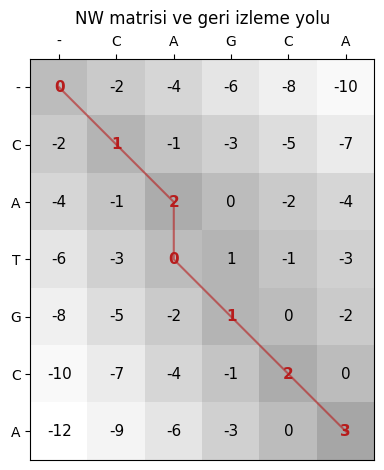

In [4]:
def dp_ciz(F, x, y, yol, baslik):
    fig, ax = plt.subplots(figsize=(0.7 * (len(y) + 2), 0.6 * (len(x) + 2)))
    ax.imshow(F, cmap="Greys", alpha=0.35)
    for i in range(F.shape[0]):
        for j in range(F.shape[1]):
            kalin = (i, j) in yol
            ax.text(j, i, F[i, j], ha="center", va="center", fontsize=11,
                    fontweight="bold" if kalin else "normal", color="#b71c1c" if kalin else "black")
    yy, xx = zip(*yol)
    ax.plot(xx, yy, color="#b71c1c", lw=1.5, alpha=0.6)
    ax.set_xticks(range(len(y) + 1)); ax.set_xticklabels(["-"] + list(y))
    ax.set_yticks(range(len(x) + 1)); ax.set_yticklabels(["-"] + list(x))
    ax.xaxis.tick_top(); ax.set_title(baslik, pad=25); plt.tight_layout(); plt.show()

dp_ciz(F, x, y, yol, "NW matrisi ve geri izleme yolu")

## 3. Biopython ile: `PairwiseAligner`

In [5]:
from Bio import Align

hizalayici = Align.PairwiseAligner()
hizalayici.mode = "global"
hizalayici.match_score = 1
hizalayici.mismatch_score = -1
hizalayici.gap_score = -2
print(hizalayici)

hizalamalar = hizalayici.align("CATGCA", "CAGCA")
print("Skor:", hizalamalar.score, "| optimal hizalama sayısı:", len(hizalamalar))
print(hizalamalar[0])

Pairwise sequence aligner with parameters
  wildcard: None
  match_score: 1.000000
  mismatch_score: -1.000000
  open_internal_insertion_score: -2.000000
  extend_internal_insertion_score: -2.000000
  open_left_insertion_score: -2.000000
  extend_left_insertion_score: -2.000000
  open_right_insertion_score: -2.000000
  extend_right_insertion_score: -2.000000
  open_internal_deletion_score: -2.000000
  extend_internal_deletion_score: -2.000000
  open_left_deletion_score: -2.000000
  extend_left_deletion_score: -2.000000
  open_right_deletion_score: -2.000000
  extend_right_deletion_score: -2.000000
  mode: global

Skor: 3.0 | optimal hizalama sayısı: 1
target            0 CATGCA 6
                  0 ||-||| 6
query             0 CA-GCA 5



### Birden fazla optimal hizalama olabilir
`GAATTC` ile `GATTA`: aynı skoru veren iki farklı hizalama vardır. Geri izlemede eşitlik durumunda hangi yönü seçtiğimiz sonucu belirler.

In [6]:
al = hizalayici.align("GAATTC", "GATTA")
print("Skor:", al.score, "| optimal sayısı:", len(al))
for a in al:
    print(a)

Skor: 1.0 | optimal sayısı: 2
target            0 GAATTC 6
                  0 ||-||. 6
query             0 GA-TTA 5

target            0 GAATTC 6
                  0 |-|||. 6
query             0 G-ATTA 5



In [7]:
# Hizalama nesnesinden bilgi çekmek
a = hizalayici.align("ACGTTTGACCA", "ACGTGACGA")[0]
print(a)
print("Koordinatlar:\n", a.coordinates)
print("Hizalanmış bloklar:", a.aligned)
sayac = a.counts()
print(f"özdeş={sayac.identities}, farklı={sayac.mismatches}, boşluk={sayac.gaps}")
uzunluk = a.shape[1]
print(f"% özdeşlik (hizalama uzunluğuna göre) = {100 * sayac.identities / uzunluk:.1f}")

target            0 ACGTTTGACCA 11
                  0 ||||--|||.| 11
query             0 ACGT--GACGA  9

Koordinatlar:
 [[ 0  4  6 11]
 [ 0  4  4  9]]
Hizalanmış bloklar: [[[ 0  4]
  [ 6 11]]

 [[ 0  4]
  [ 4  9]]]
özdeş=8, farklı=1, boşluk=2
% özdeşlik (hizalama uzunluğuna göre) = 72.7


> **Dikkat:** "% özdeşlik" tanımı araçtan araca değişir (hizalama uzunluğu, kısa dizinin uzunluğu, boşluksuz sütun sayısı...).
Raporlarken paydayı mutlaka belirtin.

## 4. Puanlama parametrelerinin etkisi
Boşluk cezası arttıkça algoritma boşluk açmak yerine uyumsuzluğu tercih eder.

`AAAGCTTT` / `AAACGTTT` için iki aday: (a) 2 uyumsuzluk: 6·1 + 2·(−1) = 4; (b) 2 boşluk: 7·1 + 2g.
(b) ancak 7 + 2g > 4, yani g > −1.5 ise tercih edilir.

In [8]:
s1, s2 = "AAAGCTTT", "AAACGTTT"
for g in [-0.5, -1, -2, -4]:
    hizalayici.gap_score = g
    a = hizalayici.align(s1, s2)[0]
    print(f"boşluk={g:5.1f}  skor={a.score:5.1f}")
    print("   " + str(a).replace("\n", "\n   "))
hizalayici.gap_score = -2

boşluk= -0.5  skor=  6.0
   target            0 AAAGC-TTT 8
                     0 |||-|-||| 9
   query             0 AAA-CGTTT 8
   
boşluk= -1.0  skor=  5.0
   target            0 AAAGC-TTT 8
                     0 |||-|-||| 9
   query             0 AAA-CGTTT 8
   
boşluk= -2.0  skor=  4.0
   target            0 AAAGCTTT 8
                     0 |||..||| 8
   query             0 AAACGTTT 8
   
boşluk= -4.0  skor=  4.0
   target            0 AAAGCTTT 8
                     0 |||..||| 8
   query             0 AAACGTTT 8
   


## 5. Protein dizileri
Protein ailemizdeki dizileri basit bir puanlamayla hizalayalım (7. haftada BLOSUM matrislerini göreceğiz).

In [9]:
from Bio import SeqIO
prot = {r.id: r.seq for r in SeqIO.parse("veri/protein_ailesi.fasta", "fasta")}
print({k: len(v) for k, v in prot.items()})

hp = Align.PairwiseAligner(mode="global", match_score=2, mismatch_score=-1,
                           open_gap_score=-5, extend_gap_score=-1)
a = hp.align(prot["protA1"], prot["protA2"])[0]
print(a)

{'protA1': 158, 'protA2': 158, 'protA3': 158, 'protA4': 158, 'protA5': 158, 'protB1': 159, 'protB2': 159, 'protB3': 156, 'ilgisiz1': 150}
target            0 MDLLTDFNLSLRRRMSNDSKSQQEHDVSYVAYLKKTQMAQIKIMLDLRNLVFRVIAAFDA
                  0 |||||||||||||||.|||||||||||||.||||||||||||||||||||||||||||||
query             0 MDLLTDFNLSLRRRMFNDSKSQQEHDVSYLAYLKKTQMAQIKIMLDLRNLVFRVIAAFDA

target           60 QGDTILYTNKEVLLLPASLLKKNGAPNKILVGLLPELVSGVDESLVWYTLDGLCAIKAAL
                 60 ||||.|||||||.|||.|||||||||||||||||||||||||.|||.|||||||.|||||
query            60 QGDTLLYTNKEVMLLPGSLLKKNGAPNKILVGLLPELVSGVDQSLVYYTLDGLCRIKAAL

target          120 VCSFNRVPPQGMRKLRDLMVPFTPVSVGLEGDTAHIRA 158
                120 |||||||||||||.|||..||||||.||||||||.||| 158
query           120 VCSFNRVPPQGMRVLRDMLVPFTPVDVGLEGDTAEIRA 158



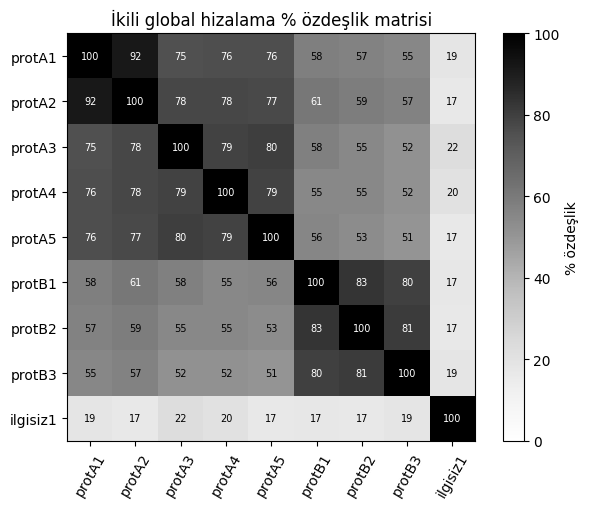

In [10]:
def ozdeslik(a, b, hizalayici=hp):
    h = hizalayici.align(a, b)[0]
    c = h.counts()
    return 100 * c.identities / h.shape[1]

isimler = list(prot)
Mtx = pd.DataFrame([[ozdeslik(prot[i], prot[j]) for j in isimler] for i in isimler], index=isimler, columns=isimler)
plt.figure(figsize=(6.5, 5.2))
plt.imshow(Mtx, cmap="Greys", vmin=0, vmax=100)
plt.xticks(range(len(isimler)), isimler, rotation=60); plt.yticks(range(len(isimler)), isimler)
for i in range(len(isimler)):
    for j in range(len(isimler)):
        plt.text(j, i, f"{Mtx.iloc[i,j]:.0f}", ha="center", va="center", fontsize=7,
                 color="white" if Mtx.iloc[i, j] > 60 else "black")
plt.colorbar(label="% özdeşlik"); plt.title("İkili global hizalama % özdeşlik matrisi"); plt.tight_layout(); plt.show()

**Yorum:** A alt ailesi kendi içinde, B alt ailesi kendi içinde daha benzer. `ilgisiz1` ile özdeşlik ≈ %10–20 civarı:
rastgele iki protein bile global hizalamada boşluklar sayesinde bir miktar "özdeşlik" gösterir. Bu nedenle **istatistiksel anlamlılık**
(7–8. haftalar) önemlidir.

## 6. Karmaşıklık: zaman ve bellek
NW algoritması $O(mn)$ zaman ve (tam matris saklanırsa) $O(mn)$ bellek kullanır.

| Dizi uzunlukları | Hücre sayısı | 8 bayt/hücre bellek |
|---|---|---|
| 1 000 × 1 000 | 10⁶ | 8 MB |
| 10 000 × 10 000 | 10⁸ | 800 MB |
| 1 Mbp × 1 Mbp | 10¹² | 8 TB (!) |

Hirschberg algoritması (böl-ve-yönet) belleği $O(\min(m,n))$'e indirir.

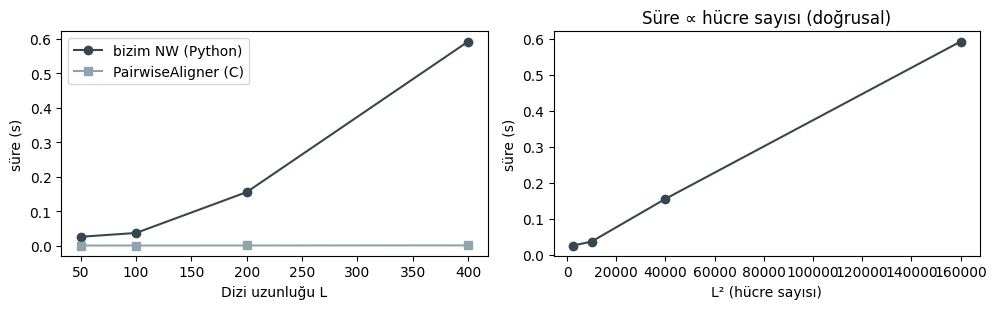

In [11]:
import time, random
random.seed(0)
uz, t_py, t_bio = [50, 100, 200, 400], [], []
for L in uz:
    a_ = "".join(random.choices("ACGT", k=L)); b_ = "".join(random.choices("ACGT", k=L))
    t = time.time(); needleman_wunsch(a_, b_); t_py.append(time.time() - t)
    t = time.time(); hizalayici.score(a_, b_); t_bio.append(time.time() - t)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(uz, t_py, "o-", label="bizim NW (Python)", color="#37474f")
ax[0].plot(uz, t_bio, "s-", label="PairwiseAligner (C)", color="#90a4ae")
ax[0].set_xlabel("Dizi uzunluğu L"); ax[0].set_ylabel("süre (s)"); ax[0].legend()
ax[1].plot(np.array(uz) ** 2, t_py, "o-", color="#37474f"); ax[1].set_xlabel("L² (hücre sayısı)"); ax[1].set_ylabel("süre (s)")
ax[1].set_title("Süre ∝ hücre sayısı (doğrusal)"); plt.tight_layout(); plt.show()

## 7. Alıştırmalar
1. `GATTACA` ile `GCATGCA` dizilerini **elle** hizalayın (eşleşme +1, uyumsuzluk −1, boşluk −2). Matrisi doldurup skoru bulun, sonra kodla kontrol edin.
2. `needleman_wunsch` fonksiyonunu yalnızca skoru döndüren ve **iki satırlık** bellek kullanan bir sürüme dönüştürün. Sonucu doğrulayın.
3. Yarı-global hizalama: `PairwiseAligner` ile uç boşluklarını cezalandırmayın (`end_gap_score = 0`). Kısa bir okumayı (`ACGTGA`) uzun bir dizi (`TTTTACGTGATTTT`) içinde hizalayıp global hizalamayla karşılaştırın.
4. `protA1` ile `ilgisiz1` arasındaki global skoru hesaplayın. Sonra `ilgisiz1` dizisini 100 kez rastgele karıştırıp (shuffle) skor dağılımını çizin. Gerçek skor bu dağılımın neresinde?

---
## Çözümler

1) skor: 1
   GATTACA
   GCATGCA
2) iki satırlı skor: 1 (aynı olmalı)
3) global skor: -10.0 (uç boşlukları 8 x -2 ceza)
   yarı-global skor: 6.0 (uç boşlukları ücretsiz)
target            0 TTTTACGTGATTTT 14
                  0 ----||||||---- 14
query             0 ----ACGTGA----  6



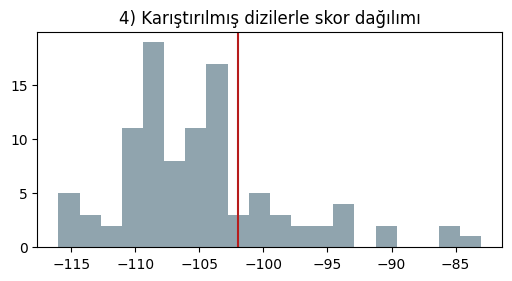

   gerçek skor=-102.0, karıştırılmış ort.=-104.9 ± 6.5 -> z = 0.45


In [12]:
# 1
F1, a1, b1, yol1 = needleman_wunsch("GATTACA", "GCATGCA")
print("1) skor:", F1[-1, -1]); print("  ", a1); print("  ", b1)

# 2
def nw_skor_iki_satir(x, y, e=1, u=-1, g=-2):
    onceki = [j * g for j in range(len(y) + 1)]
    for i in range(1, len(x) + 1):
        simdi = [i * g] + [0] * len(y)
        for j in range(1, len(y) + 1):
            s = e if x[i - 1] == y[j - 1] else u
            simdi[j] = max(onceki[j - 1] + s, onceki[j] + g, simdi[j - 1] + g)
        onceki = simdi
    return onceki[-1]
print("2) iki satırlı skor:", nw_skor_iki_satir("GATTACA", "GCATGCA"), "(aynı olmalı)")

# 3
yg = Align.PairwiseAligner(mode="global", match_score=1, mismatch_score=-1, gap_score=-2)
print("3) global skor:", yg.score("TTTTACGTGATTTT", "ACGTGA"), "(uç boşlukları 8 x -2 ceza)")
yg.end_gap_score = 0
print("   yarı-global skor:", yg.score("TTTTACGTGATTTT", "ACGTGA"), "(uç boşlukları ücretsiz)")
print(yg.align("TTTTACGTGATTTT", "ACGTGA")[0])

# 4
gercek = hp.score(prot["protA1"], prot["ilgisiz1"])
random.seed(1)
kar = []
for _ in range(100):
    l = list(str(prot["ilgisiz1"])); random.shuffle(l)
    kar.append(hp.score(prot["protA1"], "".join(l)))
plt.figure(figsize=(6, 2.8)); plt.hist(kar, bins=20, color="#90a4ae"); plt.axvline(gercek, color="#b71c1c")
plt.title("4) Karıştırılmış dizilerle skor dağılımı"); plt.show()
print(f"   gerçek skor={gercek}, karıştırılmış ort.={np.mean(kar):.1f} ± {np.std(kar):.1f} -> z = {(gercek-np.mean(kar))/np.std(kar):.2f}")